# Fast fusion surrogates: training and inference

The two methods that won `fusion_comparison.ipynb` — **M4**, a Gaussian process whose kernel
adds per-block RBFs and three cross-block *product* kernels, and **M7**, regularised
gradient-boosted trees — now live in `tackai.fusion` as classes. This notebook trains them on
the curated TACK data and shows how to score new molecules with the saved ensembles.

Two things differ from the notebook they came from:

* **No PCA runs in the pipeline.** The biological context arrives already reduced from
  `TACKAI_CACHE` (47-d cell lines, 51-d POI, 7-d E3 ligase, 8-d assay — the winners of
  `context_embeddings.ipynb`, `protein_pooling_comparison.ipynb` and `assay_embeddings.ipynb`),
  and the molecular blocks stay raw: 1024 Morgan bits and 217 RDKit descriptors, unscaled.
* **The GP is plain torch.** Pairwise distances never change while the lengthscales are being
  fitted, so they are cached per block. That is what pays for the raw 1024-column fingerprint,
  and it makes the posterior variance exact and free.

The descriptor block gets **ARD** (one lengthscale per column) for a specific reason: with no
scaler, `Ipc` reaches 1e20 while `FractionCSP3` is ~0.3, and no single lengthscale fits both.

In [1]:
import os
import sys
import time
import warnings

# macOS: torch and xgboost each bundle their own libomp and segfault when both run
# multi-threaded in one process. Must happen before either import.
os.environ.setdefault("OMP_NUM_THREADS", "1")

import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import xgboost
from dotenv import find_dotenv, load_dotenv
from scipy.stats import spearmanr
from sklearn.metrics import r2_score, roc_auc_score
from sklearn.model_selection import GroupKFold

from tackai.data.utils import get_cache_dir
from tackai.fusion import (FusionData, FusionEnsemble, GPInteraction, XGBoostFusion,
                           MolFeaturizer)

warnings.filterwarnings("ignore", category=FutureWarning)
sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.width", 160)
pd.set_option("display.precision", 3)

load_dotenv(find_dotenv(usecwd=True))
REPO_ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "pyproject.toml").exists())
DEV_FILES = [REPO_ROOT / "data/yaochen/AutoTPDplus-PROTAC-training.csv",
             REPO_ROOT / "data/yaochen/TACKv2.csv"]
ENSEMBLE_DIR = REPO_ROOT / "ensembles"

# Knobs. N_MEMBERS=5 because the speed study found five members about as accurate as
# twenty-five at a quarter of the cost. Fitting is resumable: a saved ensemble is reloaded.
TASKS = [t for t in os.environ.get("FUSION_TASKS", "dmax,pdc50,activity").split(",") if t]
N_MEMBERS = int(os.environ.get("FUSION_N_MEMBERS", "5"))

print(f"python {sys.version.split()[0]} | torch {torch.__version__} | "
      f"xgboost {xgboost.__version__} | numpy {np.__version__}")
print(f"TACKAI_CACHE -> {get_cache_dir()}")
print(f"tasks {TASKS} | members per ensemble {N_MEMBERS}")

python 3.12.4 | torch 2.11.0 | xgboost 3.2.0 | numpy 2.5.3
TACKAI_CACHE -> /Users/ribes/.cache/tackai
tasks ['dmax', 'pdc50', 'activity'] | members per ensemble 5


## 1. Data

`FusionData` is the whole data layer: it harmonises the curated CSVs, looks up every context
embedding, featurises the molecules, derives generic Murcko scaffold groups and generates the
scaffold-grouped cross-validation splits.

Some rows cannot be encoded — one POI sequence and forty cell accessions are absent from the
cached tables, and some rows carry no ligase sequence at all. They are dropped and counted,
because a training table that refuses to build is worse than one that is a few percent
smaller. Inference is stricter: an unknown sequence there *raises*, so a typo in a screening
request is never silently replaced by the wrong protein.

In [2]:
t0 = time.time()
data = FusionData.from_csv(DEV_FILES, verbose=True)
print(f"built in {time.time() - t0:.1f}s")

layout = pd.DataFrame({"block": list(data.dims), "width": list(data.dims.values())})
layout["columns"] = [f"{data.index[b][0]}..{data.index[b][-1]}" for b in data.dims]
layout["source"] = ["on the fly (Morgan r=16)", "on the fly (RDKit, 217)", "esm2 l30 mean_rm_pc2",
                    "all-mpnet mean", "esm2 l18 lse", "all-mpnet mean (open20)",
                    "mean(DC50_h, Dmax_h)"]
print()
print(layout.to_string(index=False))
print(f"\ndesign matrix: {data.X.shape[0]} rows x {data.X.shape[1]} columns")

rows = []
for task in ("dmax", "pdc50", "activity"):
    idx, X, y, groups = data.task_rows(task)
    sizes = np.unique(groups, return_counts=True)[1]
    rows.append({"task": task, "rows": len(y), "scaffold groups": len(sizes),
                 "largest group": f"{sizes.max()} ({sizes.max() / len(y):.1%})",
                 "singletons": f"{(sizes == 1).mean():.0%}",
                 "target": f"{y.mean():.3f} +/- {y.std():.3f}"})
print()
print(pd.DataFrame(rows).to_string(index=False))

table: 8432 rows read, 389 dropped (context not in the cache: poi 136, e3 120, cell 133) -> 8043 kept


built in 5.2s

      block  width    columns                   source
fingerprint   1024    0..1023 on the fly (Morgan r=16)
descriptors    217 1024..1240  on the fly (RDKit, 217)
         e3      7 1241..1247     esm2 l30 mean_rm_pc2
       cell     47 1248..1294           all-mpnet mean
        poi     51 1295..1345             esm2 l18 lse
      assay      8 1346..1353  all-mpnet mean (open20)
 assay_time      1 1354..1354     mean(DC50_h, Dmax_h)

design matrix: 8043 rows x 1355 columns

    task  rows  scaffold groups largest group singletons          target
    dmax  4190             1425     46 (1.1%)        33% 0.731 +/- 0.283
   pdc50  6962             2213     94 (1.4%)        29% 7.454 +/- 1.272
activity  4570             1561     79 (1.7%)        31% 0.426 +/- 0.494


## 2. One model on one fold

Before any ensemble, the two estimators on a single scaffold-grouped fold of pDC50. Both take
the same design matrix; everything that must be fitted inside a fold (imputation, scaling,
target standardisation, hyper-parameters) is fitted on the training rows alone.

In [3]:
FOLD_TASK = "pdc50" if "pdc50" in TASKS else TASKS[0]
idx, X, y, groups = data.task_rows(FOLD_TASK)
train, test = data.splits(FOLD_TASK, n_repeats=1, n_folds=5)[0][0]
print(f"{FOLD_TASK}: train {len(train)} rows / test {len(test)} rows, "
      f"{len(set(groups[train]) & set(groups[test]))} shared scaffold groups")

fits = {}
for name, estimator in [("M4 GP", GPInteraction(random_state=0)),
                        ("M7 XGBoost", XGBoostFusion(random_state=0))]:
    t0 = time.time()
    estimator.fit(X[train], y[train], groups[train])
    elapsed = time.time() - t0
    if estimator.supports_std:
        pred, std = estimator.predict(X[test], return_std=True)
    else:
        pred, std = estimator.predict(X[test]), None
    fits[name] = {"model": estimator, "pred": pred, "std": std,
                  "r2": r2_score(y[test], pred),
                  "rho": spearmanr(y[test], pred).statistic, "fit_s": elapsed}
    extra = f", mean sigma {std.mean():.3f}" if std is not None else ""
    print(f"{name:12s} fit {elapsed:6.1f}s   R2 {fits[name]['r2']:.3f}   "
          f"Spearman {fits[name]['rho']:.3f}{extra}")

pdc50: train 5610 rows / test 1352 rows, 0 shared scaffold groups


M4 GP        fit   56.0s   R2 0.578   Spearman 0.750, mean sigma 0.667


M7 XGBoost   fit   31.3s   R2 0.595   Spearman 0.772


### What the GP's kernel learned

The weight column is each term's share of the prior variance. The three product terms are the
interactions M4 exists for: a molecule's effect is allowed to depend on the target, the cell
line, and the pairing of the two.

In [4]:
report = fits["M4 GP"]["model"].kernel_report_
terms = pd.DataFrame({"term": list(report["weight"]), "weight": list(report["weight"].values())})
terms = terms.sort_values("weight", ascending=False)
print(terms.to_string(index=False))
print(f"\nnoise {report['noise']:.4f}")
print("lengthscales:")
for block, value in report["lengthscale"].items():
    if np.ndim(value) == 0:
        print(f"  {block:12s} {float(value):.3f}")
    else:
        print(f"  {block:12s} ARD over {len(value)} columns: "
              f"median {np.median(value):.3f}, range {value.min():.2e} .. {value.max():.2e}")

             term    weight
     prod:mol*poi 3.686e-01
  rbf:fingerprint 2.937e-01
           rbf:e3 1.553e-01
    prod:poi*cell 6.168e-02
    prod:mol*cell 5.205e-02
          rbf:poi 4.344e-02
  rbf:descriptors 1.531e-02
        rbf:assay 5.932e-03
         rbf:cell 3.344e-03
linear:assay_time 5.722e-04

noise 0.0431
lengthscales:
  fingerprint  0.749
  descriptors  ARD over 217 columns: median 3.101, range 4.33e-04 .. 5.50e+17
  e3           0.123
  cell         0.219
  poi          0.113
  assay        0.328


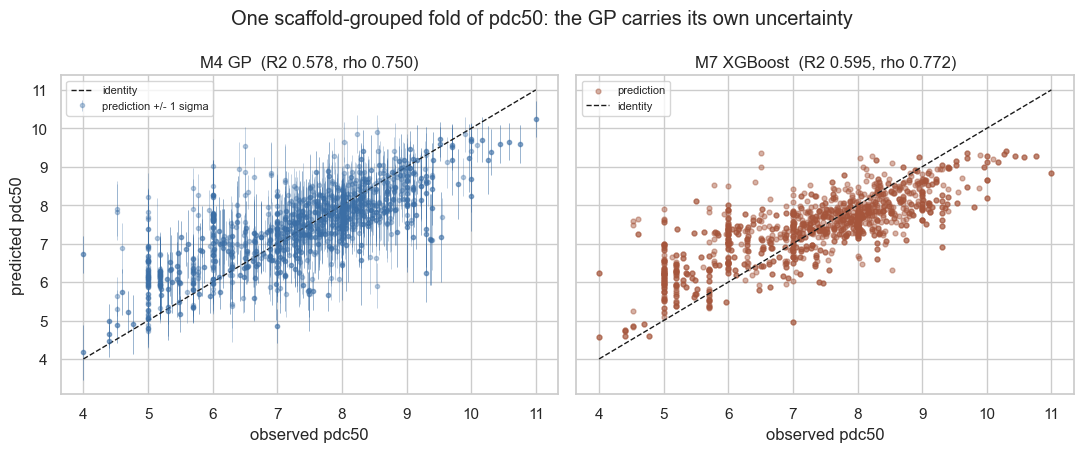

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.6), sharex=True, sharey=True)
for ax, (name, fit) in zip(axes, fits.items()):
    if fit["std"] is not None:
        ax.errorbar(y[test], fit["pred"], yerr=fit["std"], fmt="o", ms=3, alpha=0.35,
                    elinewidth=0.6, capsize=0, color="#3b6ea5", label="prediction +/- 1 sigma")
    else:
        ax.scatter(y[test], fit["pred"], s=12, alpha=0.45, color="#a5553b", label="prediction")
    lims = [min(y[test].min(), fit["pred"].min()), max(y[test].max(), fit["pred"].max())]
    ax.plot(lims, lims, "k--", lw=1, label="identity")
    ax.set_title(f"{name}  (R2 {fit['r2']:.3f}, rho {fit['rho']:.3f})")
    ax.set_xlabel(f"observed {FOLD_TASK}")
    ax.legend(loc="upper left", fontsize=8)
axes[0].set_ylabel(f"predicted {FOLD_TASK}")
fig.suptitle(f"One scaffold-grouped fold of {FOLD_TASK}: the GP carries its own uncertainty")
fig.tight_layout()
plt.show()

## 3. Ensembles

`FusionEnsemble.fit` fits one member per cross-validation fold. To keep the evaluation honest,
one fold is held out entirely first, the members are fitted on splits of the remaining rows,
and the ensemble is scored on the held-out fold — so no member has seen any row it is graded on.

Fitting is resumable: an ensemble already saved under `ensembles/fusion_<task>/` is reloaded
instead of refitted.

In [6]:
def holdout_splits(groups, pool, n_folds=5):
    """Member splits drawn from the pool rows only, so the held-out fold stays untouched."""
    inner = GroupKFold(n_splits=n_folds).split(np.zeros(len(pool)), groups=groups[pool])
    return [[(pool[tr], pool[te]) for tr, te in inner]]


ensembles, scores = {}, []
for task in TASKS:
    idx, X, y, groups = data.task_rows(task)
    pool, holdout = data.splits(task, n_repeats=1, n_folds=5)[0][0]
    target = ENSEMBLE_DIR / f"fusion_{task}"

    if (target / "manifest.json").exists():
        ens = FusionEnsemble.from_pretrained(target, data=data)
        print(f"{task}: reloaded {len(ens.members)} members from {target}")
    else:
        t0 = time.time()
        ens = FusionEnsemble.fit(GPInteraction, data, task=task, n_members=N_MEMBERS,
                                 splits=holdout_splits(groups, pool), verbose=True)
        ens.save(target)
        print(f"{task}: fitted {len(ens.members)} members in {time.time() - t0:.0f}s "
              f"-> {target}")
    ensembles[task] = ens

    pred = ens.predict_matrix(X[holdout])
    metric = "ROC-AUC" if task == "activity" else "R2"
    def grade(values):
        return (roc_auc_score(y[holdout], values) if task == "activity"
                else r2_score(y[holdout], values))

    member_grades = [grade(v) for v in pred.member_predictions.values()]
    scores.append({"task": task, "held-out rows": len(holdout), "metric": metric,
                   "ensemble": grade(pred.mean),
                   "best member": max(member_grades), "mean member": np.mean(member_grades),
                   "mean sigma": pred.std.mean()})

print()
print(pd.DataFrame(scores).to_string(index=False))

dmax: reloaded 5 members from /Users/ribes/phd/TACK/ensembles/fusion_dmax


pdc50: reloaded 5 members from /Users/ribes/phd/TACK/ensembles/fusion_pdc50


activity: reloaded 5 members from /Users/ribes/phd/TACK/ensembles/fusion_activity



    task  held-out rows  metric  ensemble  best member  mean member  mean sigma
    dmax            906      R2     0.426        0.389        0.370       0.190
   pdc50           1352      R2     0.599        0.600        0.555       0.783
activity            982 ROC-AUC     0.895        0.890        0.874       0.244


## 4. Inference

`from_pretrained` and `predict` mirror `tackai.ensemble_predictor.EnsemblePredictor`. The
fast path for screening is `transform_context`: encode one experimental context once, then
throw molecules at it. Molecular features are always computed on the fly, so nothing has to
exist in a cache beforehand.

In [7]:
task = TASKS[0]
loaded = FusionEnsemble.from_pretrained(ENSEMBLE_DIR / f"fusion_{task}")
print(f"loaded {len(loaded.members)} members for {task} "
      f"({loaded.members[0].__class__.__name__}), weights {set(loaded.weights.values())}")

reference = data.table.iloc[0]
context = {"poi_seq": reference["poi_seq"], "e3_seq": reference["e3_seq"],
           "cell_id": reference["cell_key"], "assay": reference["assay_raw"],
           "assay_time": 24.0}
print(f"context: POI {reference['poi_uniprot']}, ligase {reference['e3_raw']}, "
       f"cell {reference['cell_key']}, assay {reference['assay_raw']!r}")

candidates = list(dict.fromkeys(data.table["smiles"].head(60)))[:6]
ctx = loaded.transform_context(context)
prediction = loaded.predict(candidates, context=ctx)
frame = prediction.to_frame()
frame["smiles"] = frame["smiles"].str.slice(0, 42) + "..."
print()
print(frame.to_string(index=False))
print()
print(prediction.summary())

loaded 5 members for dmax (GPInteraction), weights {0.2}
context: POI O43353, ligase CRBN, cell CVCL_0006, assay 'Capillary-based immunoassay (Simple Western)'



                                       smiles  prediction   std  ci_lower_95  ci_upper_95   ok
CC(C)(C)S(=O)(=O)c1cc2c(Nc3ccc4scnc4c3)ccn...       0.850 0.250        0.360          1.0 True
COc1cc(-c2cn(C)c(=O)c3cnccc23)cc(OC)c1CN1C...       0.844 0.255        0.343          1.0 True
COc1cc(-c2cn(C)c(=O)c3cnccc23)cc(OC)c1CN1C...       0.825 0.254        0.327          1.0 True
   COc1ccc(CCC(=O)Nc2nc3ccc(Cl)cc3s2)cc1OC...       0.844 0.255        0.345          1.0 True
Cc1ccc(F)c(S(=O)(=O)Nc2ccc(-c3nc(OC[C@H]4C...       0.862 0.255        0.362          1.0 True
Cc1cccc(C)c1Nc1nn(C)c2nc(Nc3ccc4c(c3)CN(CC...       0.865 0.256        0.364          1.0 True

Dmax (fraction): 0.848 mean over 6 molecule(s), typical uncertainty 0.254 (5 members)


### The two failure modes, on purpose

An unknown protein sequence cannot be embedded on the fly — the winning poolings are `lse`
(not in `ProteinEmbedding`) and `mean_rm_pc2`, which is fitted over a whole vocabulary and so
is undefined for one new sequence. Rather than substitute a plausible vector, the encoder
raises. A molecule RDKit cannot parse is different: it is reported as `NaN` with `ok=False`,
so one bad SMILES in a batch of a hundred thousand does not abort the batch.

In [8]:
try:
    loaded.transform_context({**context, "poi_seq": "MKKKWWWNOTINANYTABLE"})
except KeyError as exc:
    print("unknown POI sequence ->", type(exc).__name__, str(exc)[:120])

mixed = loaded.predict(["this is not a molecule", candidates[0]], context=ctx)
print("\ninvalid SMILES in a batch:")
print(mixed.to_frame()[["prediction", "std", "ok"]].to_string(index=False))

unknown POI sequence -> KeyError 'poi: sequence not in the cached table: MKKKWWWNOTINANYTABLE… — register it with register_sequence(block, sequence, embe



invalid SMILES in a batch:
 prediction  std    ok
        NaN  NaN False
       0.85 0.25  True


## 5. Screening throughput

The target use is a loop with a fixed context and a stream of new molecules. Three things make
that cheap. The context is encoded and transformed once per member; repeated molecules are
memoised by the featuriser; and — the part that actually matters — with the context fixed, six
of the GP's ten kernel terms are identical for every molecule in the batch, so
`transform_context` collapses them into two vectors per member:

    K(i, j) = sum_(b in mol) s_b . RBF_b(i, j)  +  mol(i, j) . w_j  +  c_j

A batch then pays only for the two molecular distance matrices. Without that fold the cache
saves just the encoding (a few ms) against a cross-kernel that costs ~100 ms per member, and
measures *slower* than the ordinary path.

The speed-up below is load-sensitive: measured in isolation on this machine the fold gives ~1.6x, while a run that has just reloaded three ensembles and featurised the whole table (as this notebook has) sees less. Treat the number this run prints as the pessimistic end.

In [9]:
pool_smiles = list(dict.fromkeys(data.table["smiles"]))[:512]
fresh = MolFeaturizer()

t0 = time.time(); fresh.featurize(pool_smiles); t_feat = time.time() - t0
t0 = time.time(); ctx_fast = loaded.transform_context(context); t_ctx = time.time() - t0

loaded.data.featurizer.featurize(pool_smiles)          # warm, so this measures scoring only
t0 = time.time(); _ = loaded.predict(pool_smiles, context=ctx_fast); t_fast = time.time() - t0

records = [{"smiles": s, **context} for s in pool_smiles]
t0 = time.time(); _ = loaded.predict(records); t_slow = time.time() - t0

n = len(pool_smiles)
print(f"featurisation (cold)     {t_feat * 1e3 / n:7.2f} ms/mol   -> {n / t_feat:7.0f} mol/s")
print(f"transform_context        {t_ctx * 1e3:7.2f} ms          once per context, "
      f"{len(loaded.members)} members")
print(f"scoring, context path    {t_fast * 1e6 / n:7.0f} us/mol   -> {n / t_fast:7.0f} mol/s")
print(f"scoring, ordinary path   {t_slow * 1e6 / n:7.0f} us/mol   -> {n / t_slow:7.0f} mol/s")
print(f"context cache speed-up   {t_slow / t_fast:7.2f}x")

cold = t_feat + t_fast
print(f"\nwhole loop from cold SMILES: {n / cold:.0f} mol/s "
      f"({cold / n * 1e3:.1f} ms/mol, {t_feat / cold:.0%} of it featurisation)")

fast_vals = loaded.predict(pool_smiles[:32], context=ctx_fast)
slow_vals = loaded.predict(records[:32])
print(f"the two paths agree to {np.abs(fast_vals.mean - slow_vals.mean).max():.1e} (mean) "
      f"and {np.abs(fast_vals.std - slow_vals.std).max():.1e} (sigma) -- not bit-for-bit, "
      f"because the fold sums the same terms in a different order")

featurisation (cold)       15.51 ms/mol   ->      64 mol/s
transform_context           8.37 ms          once per context, 5 members
scoring, context path        882 us/mol   ->    1134 mol/s
scoring, ordinary path      1014 us/mol   ->     986 mol/s
context cache speed-up      1.15x

whole loop from cold SMILES: 61 mol/s (16.4 ms/mol, 95% of it featurisation)
the two paths agree to 7.8e-16 (mean) and 3.3e-16 (sigma) -- not bit-for-bit, because the fold sums the same terms in a different order


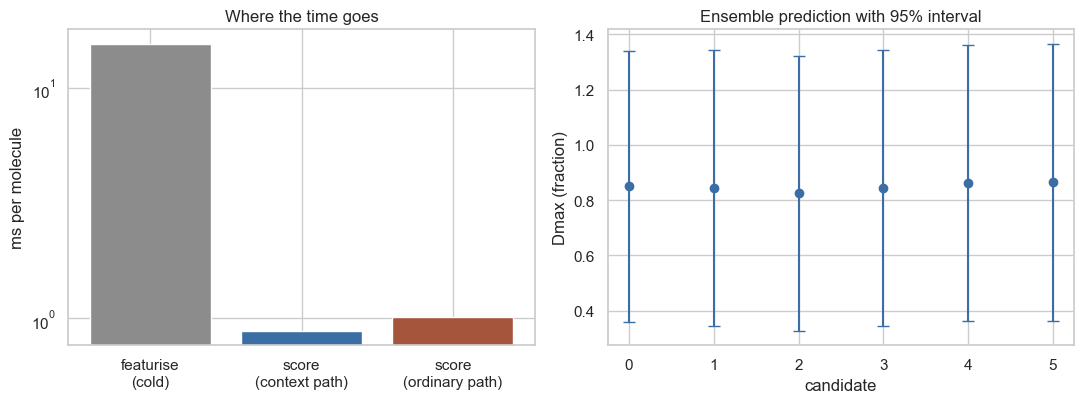

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
axes[0].bar(["featurise\n(cold)", "score\n(context path)", "score\n(ordinary path)"],
            [t_feat / n * 1e3, t_fast / n * 1e3, t_slow / n * 1e3],
            color=["#8c8c8c", "#3b6ea5", "#a5553b"])
axes[0].set_ylabel("ms per molecule")
axes[0].set_title("Where the time goes")
axes[0].set_yscale("log")

sigma = prediction.std
axes[1].errorbar(range(len(prediction.mean)), prediction.mean, yerr=1.96 * sigma, fmt="o",
                 color="#3b6ea5", capsize=4)
axes[1].set_xlabel("candidate")
axes[1].set_ylabel(prediction.label_name)
axes[1].set_title("Ensemble prediction with 95% interval")
fig.tight_layout()
plt.show()

## 6. Conclusions

In [11]:
print("For a screening or reinforcement-learning loop:")
print(f"  - FusionEnsemble.from_pretrained(ensembles/fusion_<task>) + transform_context once,")
print(f"    then predict(smiles, context=ctx): {n / cold:.0f} molecules/second from cold SMILES,")
print(f"    {t_feat / cold:.0%} of which is RDKit featurisation, not the models.")
print(f"  - The context fold makes scoring {t_slow / t_fast:.2f}x faster than re-encoding every")
print(f"    record; on a warm featuriser (an RL loop revisits molecules) that is the whole cost.")
print(f"  - The GP reports calibrated-looking uncertainty for free (exact posterior variance);")
print(f"    XGBoost does not, and an ensemble of trees falls back to member spread alone.")
print(f"  - Five members cost a fifth of twenty-five and scored within noise of them in the")
print(f"    earlier speed study; raise FUSION_N_MEMBERS if you want the full ensemble.")
print()
print("Held-out scores from this run:")
print(pd.DataFrame(scores).to_string(index=False))
print()
print("Caveat worth repeating: these are single-fold held-out numbers from one run, not the")
print("25-fold comparison in fusion_comparison.ipynb. Use that notebook for method claims.")

For a screening or reinforcement-learning loop:
  - FusionEnsemble.from_pretrained(ensembles/fusion_<task>) + transform_context once,
    then predict(smiles, context=ctx): 61 molecules/second from cold SMILES,
    95% of which is RDKit featurisation, not the models.
  - The context fold makes scoring 1.15x faster than re-encoding every
    record; on a warm featuriser (an RL loop revisits molecules) that is the whole cost.
  - The GP reports calibrated-looking uncertainty for free (exact posterior variance);
    XGBoost does not, and an ensemble of trees falls back to member spread alone.
  - Five members cost a fifth of twenty-five and scored within noise of them in the
    earlier speed study; raise FUSION_N_MEMBERS if you want the full ensemble.

Held-out scores from this run:
    task  held-out rows  metric  ensemble  best member  mean member  mean sigma
    dmax            906      R2     0.426        0.389        0.370       0.190
   pdc50           1352      R2     0.599       